In [1]:
# upload the dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\hp\Downloads\winequality.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,red


In [2]:
# Understanding the data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  good                  6497 non-null   int64  
 13  color                 6497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 710.7+ KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
good                    0
color                   0
dtype: int64

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,1,white


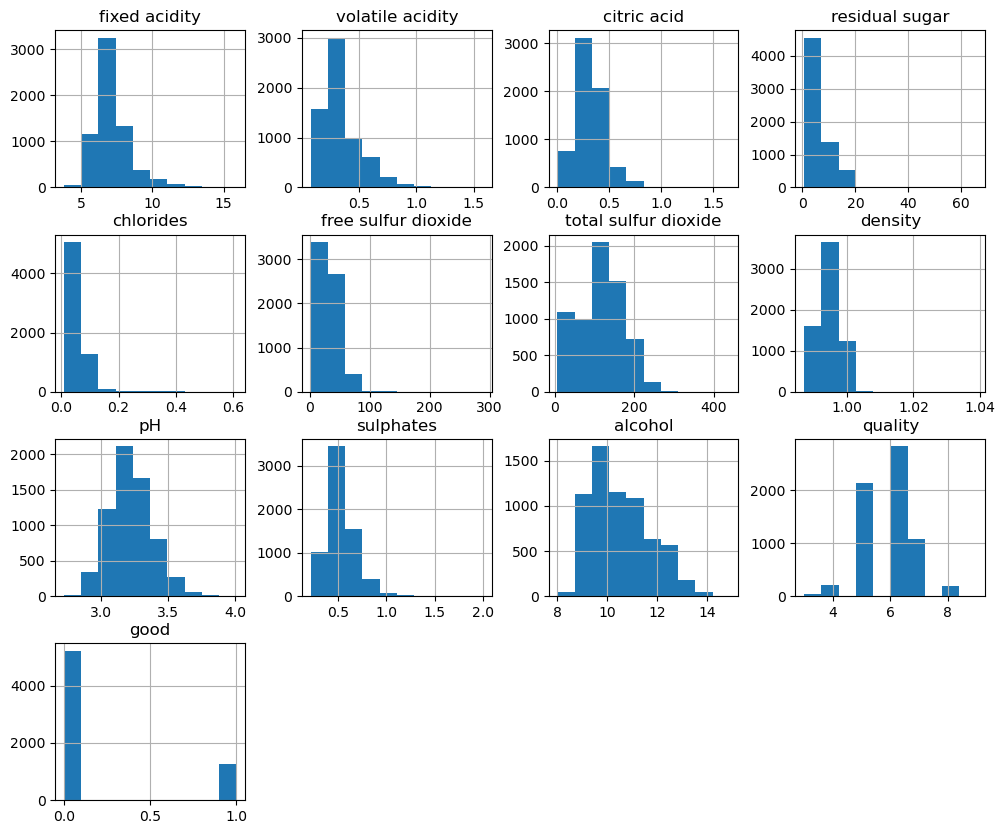

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,10))
plt.show()

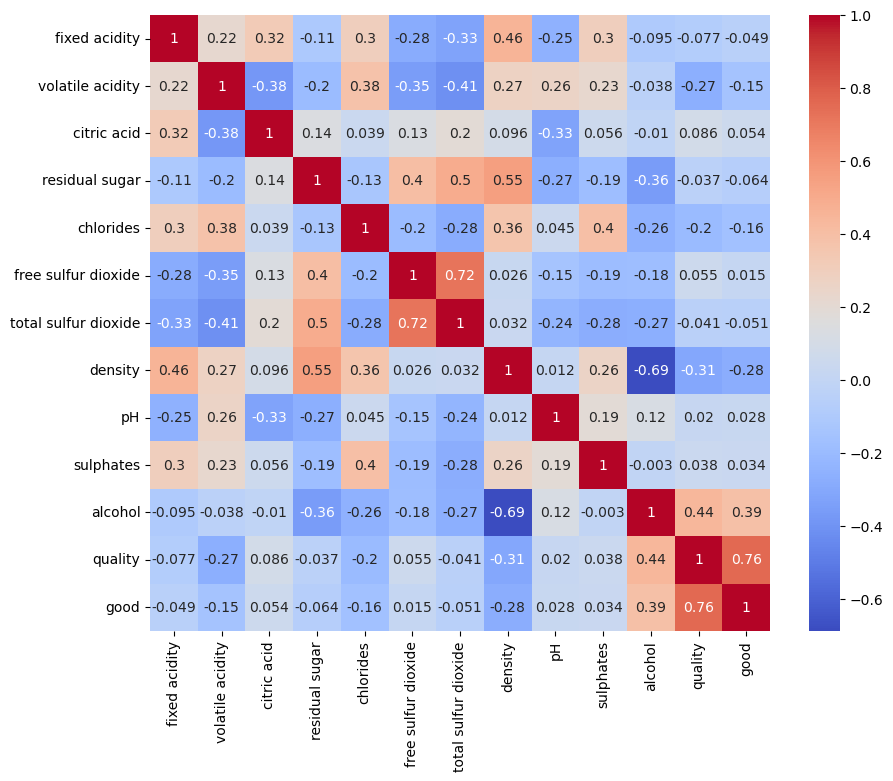

In [5]:
# Correalation Heatmap
import numpy as np

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [6]:
# Drop leakage column
if 'good' in df.columns:
    df = df.drop('good', axis=1)

In [7]:
# converted catagerical column to numarical column
df['color'] = df['color'].map({'red': 0, 'white': 1})

In [8]:
X = df.drop("quality", axis=1)  
y = df["quality"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [14]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
from sklearn.metrics import accuracy_score

models = [knn, lr, svm, dt, rf]
names = ["KNN", "Logistic", "SVM", "Decision Tree", "Random Forest"]

for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    print(name, accuracy_score(y_test, y_pred))

KNN 0.5433846153846154
Logistic 0.5316923076923077
SVM 0.5636923076923077
Decision Tree 0.5772307692307692
Random Forest 0.6713846153846154


Random Forest has the greater score compared to other models

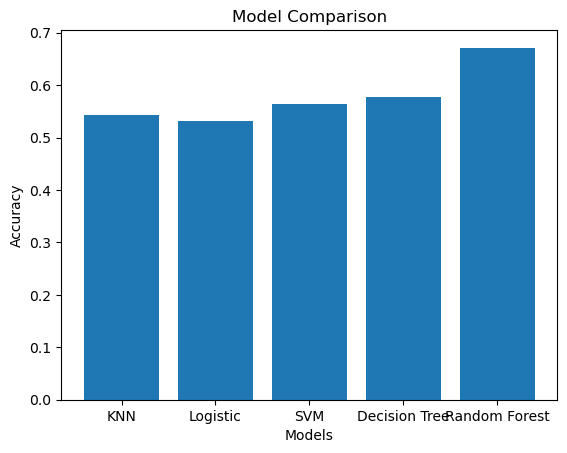

In [17]:
accuracies = []

for model in models:
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.bar(names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [18]:
# Build Model Pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

Random Forest Regressor is used  To reduce overfitting of the model.
“Initially I approached the problem as classification, but I switched to regression because wine quality is a continuous numerical score, not a true categorical label.”

In [19]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2')

print("CV Scores:", scores)
print("Mean R2:", scores.mean())

CV Scores: [0.12303619 0.27591694 0.28507548 0.3551949  0.29069566]
Mean R2: 0.2659838315584962


“The model achieved a mean R² score of around 0.27 
using 5-fold cross-validation, meaning it explains about 27% of the variance in wine quality. 
This is expected because wine quality is subjective and influenced by external factors not present in the dataset.”

In [20]:
# rain Final Model on FULL Data
rf_pipeline.fit(X, y)

Pipeline(steps=[('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

Used a pipeline to structure the model and ensure consistency during prediction.

In [21]:
# Get Feature Importance
# extracted feature importance to understand which factors most influence wine quality.
model = rf_pipeline.named_steps['model']

import pandas as pd

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feat_df)

                 Feature  Importance
10               alcohol    0.250740
1       volatile acidity    0.126902
5    free sulfur dioxide    0.089122
9              sulphates    0.078180
6   total sulfur dioxide    0.073934
3         residual sugar    0.071201
8                     pH    0.067058
4              chlorides    0.066482
2            citric acid    0.060183
7                density    0.059338
0          fixed acidity    0.055406
11                 color    0.001454


“I ensured feature order consistency to avoid prediction errors.”

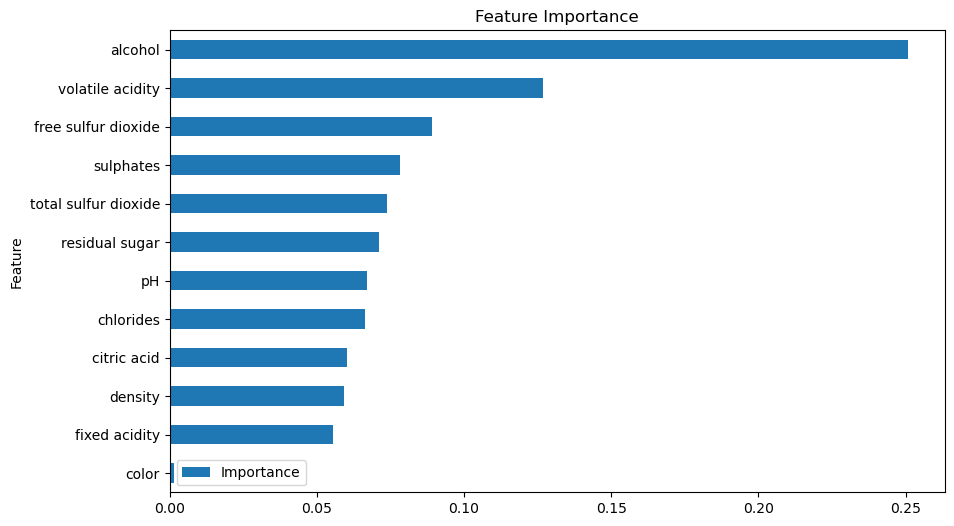

In [22]:
import matplotlib.pyplot as plt

feat_df.plot(kind='barh', x='Feature', y='Importance', figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [23]:
import joblib
joblib.dump(rf_pipeline, "wine_model.pkl")

['wine_model.pkl']

In [26]:
sample = X.iloc[0].to_dict()

prediction = model.predict(pd.DataFrame([sample]))

print("Prediction:", prediction[0])

Prediction: 5.015
